In [2]:
!pip install scikit-learn

In [3]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

In [4]:
df = pd.read_csv("clean_jobs.csv")

print(df.shape)
df.head()

(10100, 12)


,job_id,job_title,company,location,job_description,experience,education,salary,job_type,clean_description,original_length,clean_length
0,JOB07402,Frontend Developer,DataBridge Analytics,"Gurgaon, India",We are looking for a Frontend Developer to joi...,1-3 years,B.E.,9-14 LPA,Full-time,we are looking for a frontend developer to joi...,362,351
1,JOB05835,Software Engineer,Vertex Digital,"Mumbai, India",We are looking for a Software Engineer to join...,3-5 years,Bachelor's Degree,12-16 LPA,Internship,we are looking for a software engineer to join...,342,333
2,JOB02123,Machine Learning Engineer,CloudSphere,"Mumbai, India",We are looking for a Machine Learning Engineer...,1-3 years,B.E.,8-11 LPA,Full-time,we are looking for a machine learning engineer...,364,354
3,JOB08789,Cloud Engineer,Apex Solutions,"Mumbai, India",We are looking for a Cloud Engineer to join ou...,3-5 years,Master's Degree,11-16 LPA,Full-time,we are looking for a cloud engineer to join ou...,361,350
4,JOB00305,Frontend Developer,Quantix Technologies,"Noida, India",We are looking for a Frontend Developer to joi...,3-5 years,B.Tech,10-12 LPA,Full-time,we are looking for a frontend developer to joi...,366,355


In [5]:
vectorizer = TfidfVectorizer(
    max_features=1000,
    stop_words="english"
)

In [6]:
X = vectorizer.fit_transform(df["clean_description"])

In [7]:
print(X.shape)

(10100, 75)


In [8]:
terms = vectorizer.get_feature_names_out()

print(terms[:50])

['analysis' 'analyst' 'analyzing' 'api' 'aws' 'azure' 'backend' 'bi'
 'business' 'candidate' 'cloud' 'collaborating' 'communication' 'cross'
 'css' 'data' 'deliverables' 'developer' 'developing' 'devops' 'docker'
 'engineer' 'excel' 'experience' 'frontend' 'functional' 'git' 'high'
 'html' 'involves' 'java' 'javascript' 'jenkins' 'jira' 'join' 'js'
 'kubernetes' 'learn' 'learning' 'linux' 'looking' 'machine' 'maintaining'
 'node' 'numpy' 'pandas' 'postgresql' 'power' 'preferred' 'problem']


In [9]:
scores = X.sum(axis=0)

scores = scores.A1

term_scores = pd.DataFrame({
    "term": terms,
    "score": scores
})

term_scores = term_scores.sort_values(
    by="score",
    ascending=False
)

In [10]:
term_scores.head(20)

,term,score
12,communication,1188.387712
63,solutions,1105.629626
70,teams,1105.629626
23,experience,1105.629626
49,problem,1105.629626
25,functional,1105.629626
27,high,1105.629626
29,involves,1105.629626
64,solving,1105.629626
18,developing,1105.629626


In [11]:
top_terms = term_scores.head(20)

print(top_terms)

             term        score
12  communication  1188.387712
63      solutions  1105.629626
70          teams  1105.629626
23     experience  1105.629626
49        problem  1105.629626
25     functional  1105.629626
27           high  1105.629626
29       involves  1105.629626
64        solving  1105.629626
18     developing  1105.629626
53        quality  1105.629626
34           join  1105.629626
69           team  1105.629626
40        looking  1105.629626
42    maintaining  1105.629626
67         strong  1105.629626
55   requirements  1105.629626
48      preferred  1105.629626
11  collaborating  1105.629626
2       analyzing  1105.629626


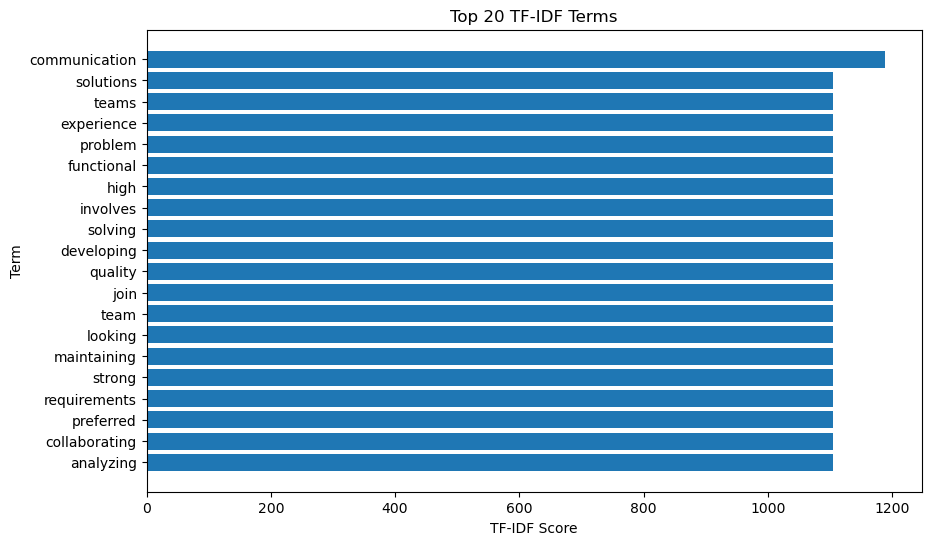

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    top_terms["term"],
    top_terms["score"]
)

plt.xlabel("TF-IDF Score")
plt.ylabel("Term")
plt.title("Top 20 TF-IDF Terms")

plt.gca().invert_yaxis()

plt.show()

In [13]:
dictionary_skills = [
    "python",
    "java",
    "sql",
    "mysql",
    "postgresql",
    "mongodb",
    "power bi",
    "tableau",
    "excel",
    "pandas",
    "numpy",
    "scikit-learn",
    "tensorflow",
    "pytorch",
    "aws",
    "azure",
    "docker",
    "kubernetes",
    "git"
]

In [14]:
tfidf_terms = set(term_scores["term"].str.lower())

matched_skills = []

for skill in dictionary_skills:
    if skill.lower() in tfidf_terms:
        matched_skills.append(skill)

print("Skills found by TF-IDF:")
print(matched_skills)

Skills found by TF-IDF:
['python', 'java', 'sql', 'postgresql', 'tableau', 'excel', 'pandas', 'numpy', 'tensorflow', 'pytorch', 'aws', 'azure', 'docker', 'kubernetes', 'git']
